In [13]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils import resample
from agents.ffnn_agent2 import FFNNAgent
from torch.utils.data import TensorDataset, DataLoader
import torch
import matplotlib.pyplot as plt
import random

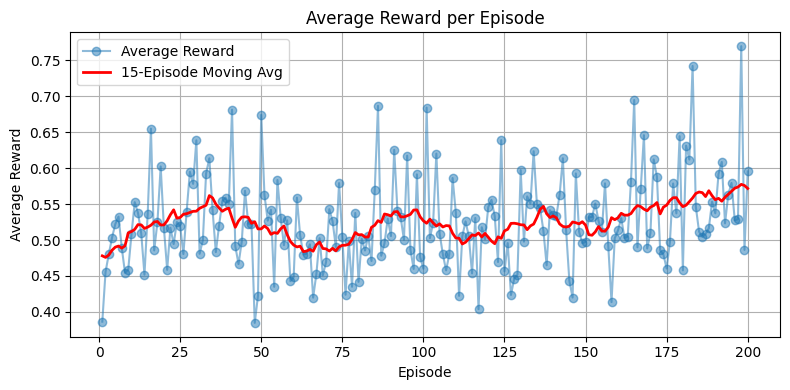

In [22]:
# Path to metrics CSV (update as needed)
run_path = "training_runs/2025-08-14_10-45-28_EP200_TRJ1000_REAL3000_BIAS0.8_L0.8/"

# Read the CSV
df_metrics = pd.read_csv(run_path + 'metrics.csv')

# Compute 15-episode moving average (centered)
window = 15
moving_avg = df_metrics['average_reward'].rolling(window=window, min_periods=1, center=True).mean()

# Plot average_reward vs episode and moving average
plt.figure(figsize=(8, 4))
plt.plot(df_metrics['episode'], df_metrics['average_reward'], marker='o', label='Average Reward', alpha=0.5)
plt.plot(df_metrics['episode'], moving_avg, color='red', linewidth=2, label=f'{window}-Episode Moving Avg')
plt.xlabel('Episode')
plt.ylabel('Average Reward')
plt.title('Average Reward per Episode')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
train_size=3000
bias_pct=0.8
seed=42
pca_components=2

In [16]:

# Ensure all randomness is seeded
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
# Fetch dataset
adult = fetch_ucirepo(id=2)
X_df = adult.data.features  
y_df = adult.data.targets   

X = X_df.values
y = np.ravel(y_df.values)

# Map labels to 0/1
y = np.where(np.isin(y, ['>50K', '>50K.']), 1, 0)

# Identify categorical and numerical columns
cat_cols = [i for i, dt in enumerate(X_df.dtypes) if dt.name in ['category', 'object', 'bool']]
num_cols = [i for i, dt in enumerate(X_df.dtypes) if np.issubdtype(dt, np.number)]

# One-hot encode categoricals, standardize numericals
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = encoder.fit_transform(X[:, cat_cols]) if cat_cols else np.empty((X.shape[0], 0))

scaler = StandardScaler()
X_num = scaler.fit_transform(X[:, num_cols]) if num_cols else np.empty((X.shape[0], 0))

# stack back together
X_all = np.hstack([X_num, X_cat])
y_all = y

# For balancing, target is last column
df_all = np.hstack([X_all, y_all.reshape(-1, 1)])

target_col = -1
majority_mask = df_all[:, target_col] == 0
minority_mask = df_all[:, target_col] == 1

df_majority = df_all[majority_mask]
df_minority = df_all[minority_mask]

# Upsample minority class
n_majority = df_majority.shape[0]
n_minority = df_minority.shape[0]

indices = np.random.choice(n_minority, size=n_majority, replace=True)
df_minority_upsampled = df_minority[indices]

# Concatenate and shuffle
df_balanced = np.vstack([df_majority, df_minority_upsampled])
np.random.shuffle(df_balanced)

X_bal = df_balanced[:, :-1]
y_bal = df_balanced[:, -1]

# Bias the dataset: remove a percentage of Class 1 examples from the balanced set
df_balanced_pd = pd.DataFrame(X_bal, columns=[f'feat_{i}' for i in range(X_bal.shape[1])])
df_balanced_pd['target'] = y_bal

# Separate class 0 and class 1
df_class_0 = df_balanced_pd[df_balanced_pd['target'] == 0]
df_class_1 = df_balanced_pd[df_balanced_pd['target'] == 1]

# Remove a fraction of class 1
df_class_1_biased = df_class_1.sample(frac=1 - bias_pct, random_state=seed)
df_biased = pd.concat([df_class_0, df_class_1_biased], axis=0).sample(frac=1, random_state=seed).reset_index(drop=True)

X_biased = df_biased.drop('target', axis=1).values
y_biased = df_biased['target'].values

# Train-test split after biasing, before PCA
X_train, X_test_theta, y_train, y_test_theta = train_test_split(
    X_biased, y_biased, test_size=0.2, random_state=seed, stratify=y_biased
)

# If train_size is specified, subsample the train set to the requested size
# Bias in class distribution is maintained.
if train_size is not None and train_size < len(X_train):
    # Stratified subsample to preserve the biased class distribution
    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, train_size=train_size, random_state=seed, stratify=y_train
            )

# PCA analysis: fit on train, transform both train and test
pca = PCA(n_components=pca_components)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test_theta)

X_train_theta = np.array(X_train_pca)
X_test_theta = np.array(X_test_pca)
y_train_theta = np.array(y_train)
y_test_theta = np.array(y_test_theta)

In [17]:
# Open a CSV of format: pca_0,pca_1,...,pca_{n-1},target and concatenate it to the trainset
# Path to the synthetic trajectory CSV
synth_csv_path = run_path + 'best_synthetic.csv'

# Read the synthetic data
synth_df = pd.read_csv(synth_csv_path)

# Dynamically determine PCA columns based on pca_components
pca_columns = [f"pca_{i}" for i in range(pca_components)]
all_columns = pca_columns + ["target"]

# Ensure the columns exist in the CSV
missing_cols = [col for col in all_columns if col not in synth_df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in synthetic CSV: {missing_cols}")

# Extract features and target dynamically
synth_X = synth_df[pca_columns].values
synth_y = synth_df["target"].values

# Concatenate synthetic data to the training set
X_train_phi = np.concatenate([X_train_theta, synth_X], axis=0)
y_train_phi = np.concatenate([y_train_theta, synth_y], axis=0)


FFNN Using device: cpu
FFNN Using device: cpu


/tmp/ipykernel_19366/277453240.py:39: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  y_pred_theta = np.array(agent_theta.predict(X_test_theta))
/tmp/ipykernel_19366/277453240.py:40: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  y_pred_phi   = np.array(agent_phi.predict(  X_test_theta))


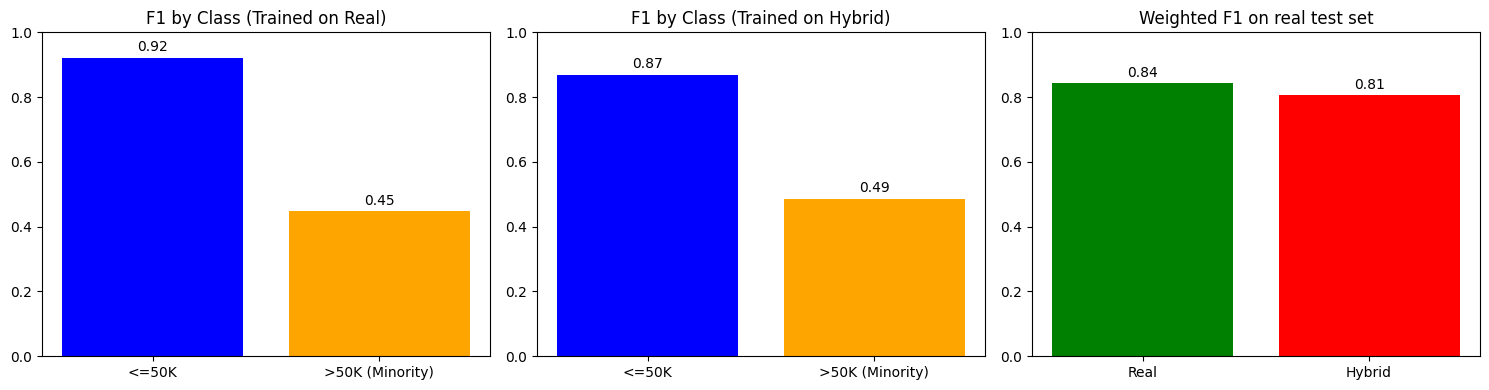

In [18]:
# --- Prepare FFNN config and agents ---
ffnn_config = {
    'input_size': X_train_theta.shape[1],
    'hidden_sizes': [32, 16],
    'output_size': 1,
    'learning_rate': 0.001,
    'batch_size': 64,
    'epochs': 10,
    'type': 'classification',
    'classes': [0, 1],
    'seed': seed
}

agent_theta = FFNNAgent(**ffnn_config)
agent_phi   = FFNNAgent(**ffnn_config)

# --- Build DataLoaders ---
theta_dataset = TensorDataset(
    torch.tensor(X_train_theta, dtype=torch.float32),
    torch.tensor(y_train_theta, dtype=torch.long)
)
phi_dataset = TensorDataset(
    torch.tensor(X_train_phi, dtype=torch.float32),
    torch.tensor(y_train_phi, dtype=torch.long)
)

theta_loader = DataLoader(theta_dataset, batch_size=ffnn_config['batch_size'],
                          shuffle=True,
                          generator=torch.Generator().manual_seed(seed))
phi_loader   = DataLoader(phi_dataset,   batch_size=ffnn_config['batch_size'],
                          shuffle=True,
                          generator=torch.Generator().manual_seed(seed))

# --- Train ---
agent_theta.train(theta_loader)
agent_phi.train(phi_loader)

# --- Predict on θ-test ---
y_pred_theta = np.array(agent_theta.predict(X_test_theta))
y_pred_phi   = np.array(agent_phi.predict(  X_test_theta))

# --- Compute overall weighted F1 once each ---
f1_theta_both = f1_score(y_test_theta, np.round(y_pred_theta), average='weighted')
f1_phi_both   = f1_score(y_test_theta, np.round(y_pred_phi),   average='weighted')

# --- Compute per-class F1s by unpacking average=None ---
f1_theta_0, f1_theta_1 = f1_score(y_test_theta, np.round(y_pred_theta), average=None)
f1_phi_0,   f1_phi_1   = f1_score(y_test_theta, np.round(y_pred_phi),   average=None)

# --- Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Trained on Theta
axes[0].bar(['<=50K', '>50K (Minority)'], [f1_theta_0, f1_theta_1], color=['blue','orange'])
axes[0].set_title('F1 by Class (Trained on Real)')
axes[0].set_ylim(0,1)
for i, v in enumerate([f1_theta_0, f1_theta_1]):
    axes[0].text(i, v+0.02, f"{v:.2f}", ha='center')

# 2. Trained on Phi
axes[1].bar(['<=50K', '>50K (Minority)'], [f1_phi_0, f1_phi_1], color=['blue','orange'])
axes[1].set_title('F1 by Class (Trained on Hybrid)')
axes[1].set_ylim(0,1)
for i, v in enumerate([f1_phi_0, f1_phi_1]):
    axes[1].text(i, v+0.02, f"{v:.2f}", ha='center')

# 3. Weighted F1 comparison (now green and red bars)
axes[2].bar(['Real','Hybrid'], [f1_theta_both, f1_phi_both], color=['green','red'])
axes[2].set_title('Weighted F1 on real test set')
axes[2].set_ylim(0,1)
for i, v in enumerate([f1_theta_both, f1_phi_both]):
    axes[2].text(i, v+0.02, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()